In [3]:
!pip install gymnasium[atari] ale-py autorom
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.11/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


1. Creando entorno de entrenamiento...


2025-12-01 22:51:42.440614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764629502.507225     303 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764629502.530334     303 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/tensorboard/compat/__init__.py", line 42, in tf
    from tensorboard.compat import notf  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ImportError: cannot import name 'notf' from 'tensorboard.compat' (/usr/local/lib/python3.11/dist-packages/tensorboard/compat/__init__.py)

During handling of the above exception, another exception occurred:

Attr

2. Definiendo el modelo DQN...
Using cuda device
Wrapping the env in a VecTransposeImage.
3. Iniciando entrenamiento por 1000000 pasos...
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 366      |
|    time_elapsed     | 1        |
|    total_timesteps  | 368      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 482      |
|    time_elapsed     | 1        |
|    total_timesteps  | 560      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 563      |
|    time_elapsed     

<Figure size 1000x500 with 0 Axes>

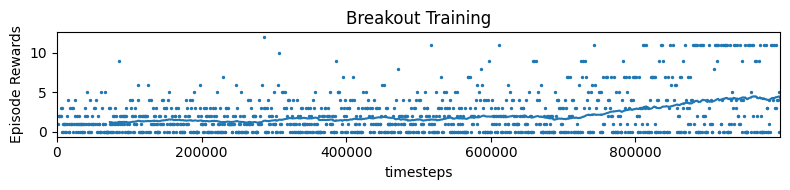


4. Iniciando evaluación final...


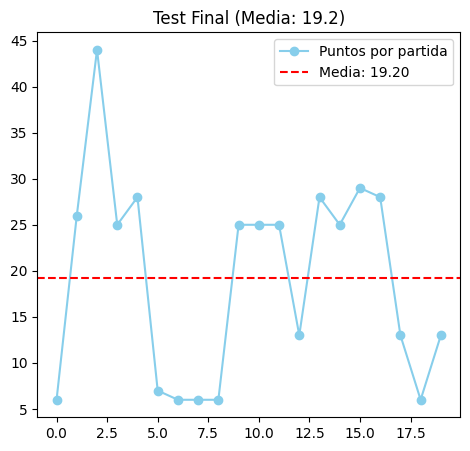

In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import os
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, SubprocVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common import results_plotter

# --- CONFIGURACIÓN GLOBAL ---
ENV_ID = "BreakoutNoFrameskip-v4"
STEPS_TRAINING = 1_000_000
N_ENVS = 8
LOG_DIR = "./metricas_entrenamiento/" # <--- Carpeta para guardar datos

os.makedirs(LOG_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. ENTRENAMIENTO
# ---------------------------------------------------------
print("1. Creando entorno de entrenamiento...")

# AGREGADO: monitor_dir=LOG_DIR
# Esto guarda automáticamente rewards y tiempos en la carpeta
train_env = make_atari_env(
    ENV_ID, 
    n_envs=N_ENVS, 
    seed=0, 
    vec_env_cls=SubprocVecEnv,
    monitor_dir=LOG_DIR  # <--- AQUÍ SE GUARDAN LAS ESTADÍSTICAS
)
train_env = VecFrameStack(train_env, n_stack=4)

print("2. Definiendo el modelo DQN...")
model = DQN(
    "CnnPolicy",
    train_env,
    buffer_size=50000,
    learning_rate=1e-4,
    batch_size=32,
    learning_starts=1000,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    verbose=1,
    device="cuda"
)

print(f"3. Iniciando entrenamiento por {STEPS_TRAINING} pasos...")
model.learn(total_timesteps=STEPS_TRAINING)
print("¡Entrenamiento finalizado!")

# ---------------------------------------------------------
# 2. GUARDADO PORTABLE
# ---------------------------------------------------------
NOMBRE_MODELO = "mi_agente_breakout.zip"
model.save(NOMBRE_MODELO)
print(f"Modelo guardado en: {NOMBRE_MODELO}")
print("Descarga este archivo .zip para usarlo en otra computadora.")

# Liberamos memoria del entorno de entrenamiento
train_env.close() 

# ---------------------------------------------------------
# 3. VISUALIZAR LA CURVA DE APRENDIZAJE (Estadísticas)
# ---------------------------------------------------------
print("Generando gráfico de evolución del entrenamiento...")
plt.figure(figsize=(10, 5))
# Esta función de SB3 lee los logs y grafica automáticamente
results_plotter.plot_results([LOG_DIR], STEPS_TRAINING, results_plotter.X_TIMESTEPS, "Breakout Training")
plt.show()

# ---------------------------------------------------------
# 4. EVALUACIÓN FINAL (Tu código original)
# ---------------------------------------------------------
print("\n4. Iniciando evaluación final...")

eval_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
eval_env = VecFrameStack(eval_env, n_stack=4)

episode_rewards, episode_lengths = evaluate_policy(
    model, 
    eval_env, 
    n_eval_episodes=20, 
    return_episode_rewards=True,
    deterministic=False
)

eval_env.close()

# Gráfico de resultados finales
mean_reward = np.mean(episode_rewards)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(episode_rewards, 'o-', color='skyblue', label='Puntos por partida')
plt.axhline(mean_reward, color='red', linestyle='--', label=f'Media: {mean_reward:.2f}')
plt.title(f'Test Final (Media: {mean_reward:.1f})')
plt.legend()
plt.show()